In [ ]:
# SHAZAM SHM MODELS 
# Este script aplica tres enfoques complementarios para analizar las mutaciones somáticas 
# en tu repertorio: primero calcula la carga mutacional global comparando cada secuencia 
# completa contra su germline, luego evalúa la distribución de mutaciones por 
# subregiones (CDR y FWR según definiciones IMGT) para distinguir entre regiones de unión
# y estructurales, y finalmente clasifica las mutaciones según propiedades fisicoquímicas
# de los aminoácidos (carga, polaridad, hidrofobicidad o volumen) para estimar su impacto
# funcional

In [2]:

library(shazam)
library(alakazam)
library(readr)
library(dplyr)
library(ggplot2)


Loading required package: ggplot2

Warning message:
"replacing previous import 'S4Arrays::makeNindexFromArrayViewport' by 'DelayedArray::makeNindexFromArrayViewport' when loading 'SummarizedExperiment'"


To cite the SHazaM package in publications, please use:

  Gupta N, Vander Heiden J, Uduman M, Gadala-Maria D, Yaari G,
  Kleinstein S (2015). "Change-O: a toolkit for analyzing large-scale B
  cell immunoglobulin repertoire sequencing data." _Bioinformatics_,
  1-3. doi:10.1093/bioinformatics/btv359
  <https://doi.org/10.1093/bioinformatics/btv359>.

To cite the selection analysis methods, please use:

  Yaari G, Uduman M, Kleinstein S (2012). "Quantifying selection in
  high-throughput Immunoglobulin sequencing data sets." _Nucleic acids
  research_, *40*(17), e134. doi:10.1093/nar/gks457
  <https://doi.org/10.1093/nar/gks457>.

To cite the HH_S5F model and the targeting model generation methods,
please use:

  Yaari G, Vander Heiden J, Uduman M, Gadala-Maria D, Gupta N, Stern J,
  

In [3]:
# MUTATION ANALYSIS SHAZAM
# 1. Cargar tu archivo
archivo_clones <- "../data/output/repertorio_A_insilico_30_seqs_clone-pass.tsv"
clones <- read_tsv(archivo_clones) %>%
  mutate(sample_id = "repertorio_simulado")

# 2. Mutaciones globales (toda la secuencia)
mut_global <- observedMutations(
  clones,
  sequenceColumn="sequence_alignment",
  germlineColumn="germline_alignment",
  regionDefinition=NULL,   # toda la secuencia
  frequency=TRUE
)

# 3. Mutaciones por subregión (CDR/FWR según IMGT)
mut_regions <- observedMutations(
  clones,
  sequenceColumn="sequence_alignment",
  germlineColumn="germline_alignment",
  regionDefinition=IMGT_V_BY_REGIONS,   # esquema IMGT con CDR/FWR
  frequency=TRUE
)


# Mutaciones globales
db_all <- mut_global[, c("mu_freq_seq_r","mu_freq_seq_s")]

# Mutaciones en CDR1 y CDR2 (R y S)
cdr_mutations <- mut_regions[, c("mu_freq_cdr1_r","mu_freq_cdr1_s",
                                 "mu_freq_cdr2_r","mu_freq_cdr2_s")]

# Mutaciones en FWR1–3 (R y S)
fwr_mutations <- mut_regions[, c("mu_freq_fwr1_r","mu_freq_fwr1_s",
                                 "mu_freq_fwr2_r","mu_freq_fwr2_s",
                                 "mu_freq_fwr3_r","mu_freq_fwr3_s")]

# Combinar todo en un solo objeto
db_selected <- cbind(db_all, cdr_mutations, fwr_mutations)

# Revisar primeras filas
head(db_selected)



Rows: 30 Columns: 50
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr (20): sequence_id, sequence, v_call, d_call, j_call, sequence_alignment,...
dbl (25): junction_length, np1_length, np2_length, v_sequence_start, v_seque...
lgl  (5): rev_comp, productive, stop_codon, vj_in_frame, c_call

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


,mu_freq_seq_r,mu_freq_seq_s,mu_freq_cdr1_r,mu_freq_cdr1_s,mu_freq_cdr2_r,mu_freq_cdr2_s,mu_freq_fwr1_r,mu_freq_fwr1_s,mu_freq_fwr2_r,mu_freq_fwr2_s,mu_freq_fwr3_r,mu_freq_fwr3_s
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.000000000,0,0,0,0,0,0,0,0,0,0,0
2,0.000000000,0,0,0,0,0,0,0,0,0,0,0
3,0.002793296,0,0,0,0,0,0,0,0,0,0,0
4,0.000000000,0,0,0,0,0,0,0,0,0,0,0
5,0.000000000,0,0,0,0,0,0,0,0,0,0,0
6,0.000000000,0,0,0,0,0,0,0,0,0,0,0


In [10]:
readr::write_tsv(db_all, "../results/mutation_model_A_30seqs.tsv")

In [6]:
# BASELINE MODEL
# 1. Cargar archivo
archivo_clones <- "../data/output/repertorio_A_insilico_30_seqs_clone-pass.tsv"
db <- read_tsv(archivo_clones) %>%
  mutate(
    sample_id = "repertorio_naive",
    clone_id = as.character(clone_id)
  ) %>%
  filter(!is.na(clone_id))

# 2. Asignar IGHM si c_call está vacío
if (all(is.na(db$c_call))) {
  db$c_call <- "IGHM"
}

# 3. Colapsar clones
clones <- collapseClones(
  db,
  cloneColumn="clone_id",
  sequenceColumn="sequence_alignment",
  germlineColumn="germline_alignment",
  regionDefinition=IMGT_V,
  method="thresholdedFreq",
  minimumFrequency=0.6,
  includeAmbiguous=FALSE,
  breakTiesStochastic=FALSE,
  nproc=1
)

# 4. Calcular selección
baseline <- calcBaseline(
  clones,
  testStatistic="focused",
  regionDefinition=IMGT_V,
  nproc=1
)

# 5. Mensaje pipeline con pdfs o no
if (length(baseline) == 0) {
  message("Pipeline ejecutado correctamente. No hay PDFs de selección porque el repertorio naïve no tiene mutaciones.")
} else {
  message("Pipeline ejecutado correctamente. Hay resultados de selección disponibles.")
}

grouped <- groupBaseline(baseline, groupBy="sample_id")

# Chequear que grouped tenga datos y la columna sample_id
if (!is.null(grouped) && nrow(grouped) > 0 && "sample_id" %in% colnames(grouped)) {
  plotBaselineSummary(grouped, idColumn="sample_id")
  plotBaselineDensity(grouped, idColumn="sample_id")
} else {
  message("No hay PDFs de selección → no se genera gráfico.")
}





Rows: 30 Columns: 50
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr (20): sequence_id, sequence, v_call, d_call, j_call, sequence_alignment,...
dbl (25): junction_length, np1_length, np2_length, v_sequence_start, v_seque...
lgl  (5): rev_comp, productive, stop_codon, vj_in_frame, c_call

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
calcBaseline will calculate observed and expected mutations for clonal_sequence using clonal_germline as a reference.



Calculating BASELINe probability density functions...


Pipeline ejecutado correctamente. Hay resultados de selecci<U+00F3>n disponibles.



Grouping BASELINe probability density functions...
Calculating BASELINe statistics...


No hay PDFs de selecci<U+00F3>n <U+2192> no se genera gr<U+00E1>fico.



In [7]:
write_tsv(grouped, "../results/repertorio_A_30seq_baseline.tsv")

ERROR: Error in write_delim(x, file, delim = "\t", na = na, append = append, : is.data.frame(x) is not TRUE


Rows: 30 Columns: 50
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr (20): sequence_id, sequence, v_call, d_call, j_call, sequence_alignment,...
dbl (25): junction_length, np1_length, np2_length, v_sequence_start, v_seque...
lgl  (5): rev_comp, productive, stop_codon, vj_in_frame, c_call

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message in createMutabilityMatrix(db, sub_mat, model = model, sequenceColumn = sequenceColumn, :
"Insufficient number of mutations to infer some 5-mers. Filled with 0. "
Pipeline ejecutado correctamente. Modelo de targeting disponible.

Warning message:
"Removed 256 rows containing missing values or values outside the scale range
(`geom_segment()`)."


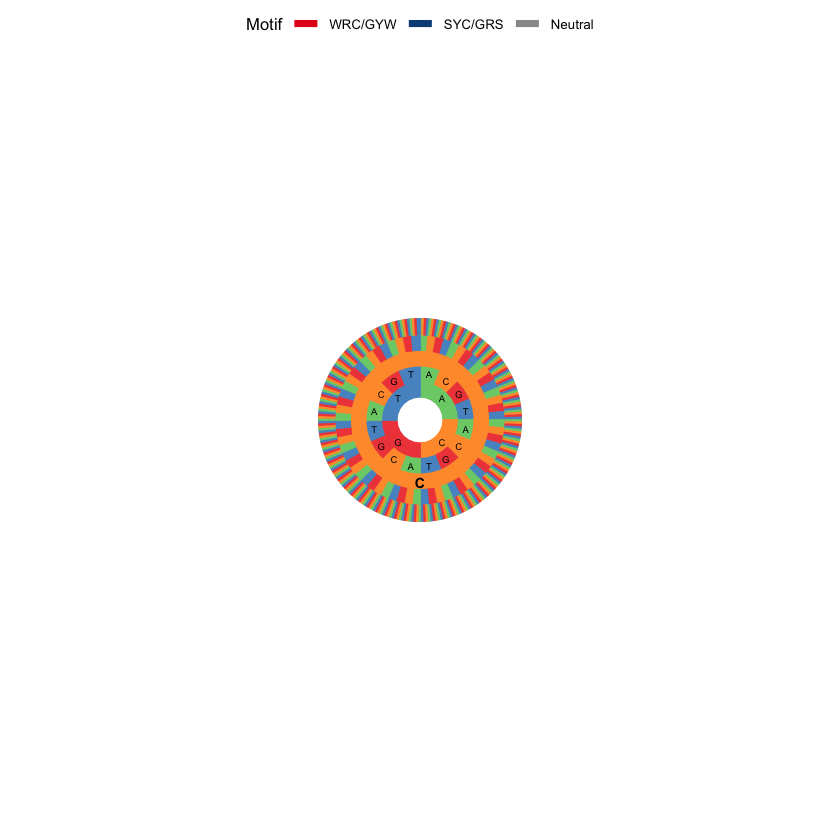

In [8]:
# TARGETING MODEL
# 1. Cargar archivo
archivo_clones <- "../data/output/repertorio_A_insilico_30_seqs_clone-pass.tsv"
db <- read_tsv(archivo_clones) %>%
  mutate(
    sample_id = "repertorio_naive",
    clone_id = as.character(clone_id)
  ) %>%
  filter(!is.na(clone_id))

# 2. Asignar IGHM si c_call está vacío
if (all(is.na(db$c_call))) {
  db$c_call <- "IGHM"
}

# 3. Colapsar clones (igual que en baseline)
clones <- collapseClones(
  db,
  cloneColumn="clone_id",
  sequenceColumn="sequence_alignment",
  germlineColumn="germline_alignment",
  regionDefinition=IMGT_V,
  method="thresholdedFreq",
  minimumFrequency=0.6,
  includeAmbiguous=FALSE,
  breakTiesStochastic=FALSE,
  nproc=1
)

# 4. Crear modelo de targeting (mutabilidad + sustitución)
targeting_model <- createTargetingModel(
  clones,
  model="s",                        # usar mutaciones silenciosas
  sequenceColumn="clonal_sequence",
  germlineColumn="clonal_germline",
  vCallColumn="v_call"
)

# 5. Mensaje pipeline
if (is.null(targeting_model) || length(targeting_model) == 0) {
  message("Pipeline ejecutado correctamente. No se generó modelo de targeting (no hay mutaciones suficientes).")
} else {
  message("Pipeline ejecutado correctamente. Modelo de targeting disponible.")
}

# 6. Visualización de mutabilidad (ejemplo con nucleótido C)
if (!is.null(targeting_model) && length(targeting_model) > 0) {
  plotMutability(targeting_model, nucleotides="C", style="hedgehog")
  
  # 7. Calcular matriz de distancias
  targeting_dist <- calcTargetingDistance(targeting_model)
} else {
  message("No se generan gráficos ni distancias → no hay modelo de targeting válido.")
}


In [12]:
# Exportar solo la matriz de distancias del targeting
write_tsv(as_tibble(targeting_dist), "../results/targeting_distances_A_30seqs.tsv")
